# 🎛️ Hyperparameter Tuning — GridSearchCV, RandomizedSearchCV, Optuna

Every algorithm notebook in this series picked hyperparameters somewhat by hand (`max_depth=4`, `C=10`, `k=7`). This topic formalizes *how* to actually find good values systematically, using the Cross-Validation machinery from the previous topic as its evaluation engine.

📖 Full mathematical explanation (search space complexity, random search's efficiency argument, Bayesian optimization): [README.md](README.md)


## 1. Setup & Dataset


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")   # cosmetic-only: optuna's optional tqdm progress bar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.metrics import accuracy_score
from scipy.stats import randint, uniform
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (455, 30), Test: (114, 30)


## 2. The Problem — Manual Tuning Doesn't Scale

With one hyperparameter, trying a handful of values by hand is fine. With several hyperparameters, the number of combinations to check by hand explodes — this is exactly the combinatorial problem grid search exists to automate.


In [3]:
manual_results = {}
for n_est in [50, 100]:
    for depth in [5, 10]:
        for min_leaf in [1, 4]:
            model = RandomForestClassifier(n_estimators=n_est, max_depth=depth, min_samples_leaf=min_leaf, random_state=42)
            score = cross_val_score(model, X_train, y_train, cv=5).mean()
            manual_results[(n_est, depth, min_leaf)] = score

best_manual = max(manual_results, key=manual_results.get)
print(f"Checked {len(manual_results)} combinations by hand -- best: {best_manual} -> {manual_results[best_manual]:.4f}")
print("-> Already tedious with just 3 hyperparameters at 2 values each (8 combos). GridSearchCV automates exactly this loop.")


Checked 8 combinations by hand -- best: (100, 10, 4) -> 0.9582
-> Already tedious with just 3 hyperparameters at 2 values each (8 combos). GridSearchCV automates exactly this loop.


## 3. Grid Search — Exhaustive Search Over a Parameter Grid

`GridSearchCV` tries **every combination** in a specified grid, cross-validating each one, and keeps the best. It reproduces section 2's manual loop exactly, but manages the bookkeeping automatically.


In [4]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_leaf": [1, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="accuracy"
)
grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10], 'min_samples_leaf': [1, 4], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose

In [5]:
grid_best_tuple = (grid_search.best_params_["n_estimators"], grid_search.best_params_["max_depth"], grid_search.best_params_["min_samples_leaf"])

print(f"GridSearchCV best:  {grid_search.best_params_} -> {grid_search.best_score_:.4f}")
print(f"Manual loop best:   {dict(zip(['n_estimators','max_depth','min_samples_leaf'], best_manual))} -> {manual_results[best_manual]:.4f}")
print(f"Same combination?   {grid_best_tuple == best_manual}")
print("\n-> If these differ, it's usually because the CV fold split itself differs (GridSearchCV here uses a")
print("   SHUFFLED StratifiedKFold, section 2's manual loop used cross_val_score's un-shuffled default) --")
print("   with several combinations scoring within noise of each other (see section 17), a different")
print("   fold shuffle can genuinely shift which one comes out narrowly on top.")


GridSearchCV best:  {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100} -> 0.9626
Manual loop best:   {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 4} -> 0.9582
Same combination?   False

-> If these differ, it's usually because the CV fold split itself differs (GridSearchCV here uses a
   SHUFFLED StratifiedKFold, section 2's manual loop used cross_val_score's un-shuffled default) --
   with several combinations scoring within noise of each other (see section 17), a different
   fold shuffle can genuinely shift which one comes out narrowly on top.


## 4. Visualizing the Grid Search Landscape

Every combination's CV score, laid out as a heatmap, makes the search space directly visible — including which hyperparameters matter more (steeper score gradients) and which barely move the needle.


In [6]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["params_str"] = results_df["params"].astype(str)
pivot = results_df.pivot_table(values="mean_test_score", index="param_max_depth", columns="param_n_estimators", aggfunc="mean")


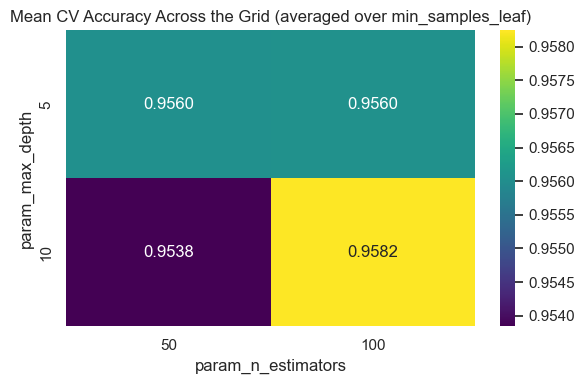

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis", ax=ax)
ax.set_title("Mean CV Accuracy Across the Grid (averaged over min_samples_leaf)")
plt.tight_layout()
plt.show()


## 5. The Cost of Grid Search — Combinatorial Explosion

Grid search's cost is the **product** of each hyperparameter's option count, times the number of CV folds. Adding one more hyperparameter with a few options multiplies, not adds, to the total number of model fits required.


In [8]:
grid_sizes = []
for n_params_values in [2, 3, 4, 5]:
    combos = n_params_values ** 3   # 3 hyperparameters, each with n_params_values options
    total_fits = combos * 5          # x5 for cross-validation folds
    grid_sizes.append({"values_per_param": n_params_values, "combinations": combos, "total_model_fits": total_fits})

pd.DataFrame(grid_sizes)


,values_per_param,combinations,total_model_fits
0,2,8,40
1,3,27,135
2,4,64,320
3,5,125,625


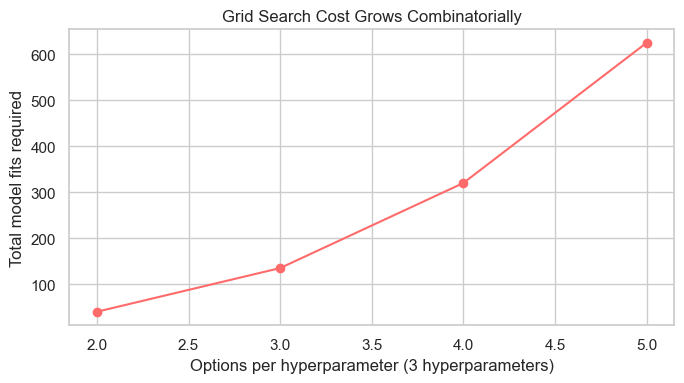

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sizes = pd.DataFrame(grid_sizes)
ax.plot(sizes["values_per_param"], sizes["total_model_fits"], marker="o", color="#ff6b6b")
ax.set_xlabel("Options per hyperparameter (3 hyperparameters)")
ax.set_ylabel("Total model fits required")
ax.set_title("Grid Search Cost Grows Combinatorially")
plt.tight_layout()
plt.show()


## 6. Random Search — Sampling Instead of Exhausting

`RandomizedSearchCV` samples a fixed *number* of random combinations from specified distributions, instead of trying every single one. Same evaluation mechanism (cross-validation), fundamentally different search strategy.


In [10]:
param_distributions = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(3, 20),
    "min_samples_leaf": randint(1, 10),
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), param_distributions,
    n_iter=20, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="accuracy", random_state=42
)
random_search.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....0021D1CA091D0>, 'min_samples_leaf': <scipy.stats....0021D1CA5CE10>, 'n_estimators': <scipy.stats....0021D1CA3AA50>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly 

In [11]:
print(f"Best parameters: {random_search.best_params_}")
print(f"Best CV score:    {random_search.best_score_:.4f}")
print(f"Number of combinations tried: 20 (vs. {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_leaf'])} for the small grid above)")


Best parameters: {'max_depth': 19, 'min_samples_leaf': 3, 'n_estimators': 157}
Best CV score:    0.9604
Number of combinations tried: 20 (vs. 8 for the small grid above)


## 7. Grid vs Random — Same Budget, Different Coverage

With an EQUAL number of model fits allowed, comparing grid search (constrained to a small grid that fits the budget) against random search (sampling freely from continuous ranges) on which one finds a better configuration.


In [12]:
budget = 20   # exactly 20 model-fit "slots" for both approaches

# Grid search: to hit ~20 combos with a grid, we're forced into a coarse grid
coarse_grid = {"n_estimators": [50, 150, 250], "max_depth": [5, 10], "min_samples_leaf": [1, 3, 5, 8]}
n_combos = 3 * 2 * 4
print(f"Coarse grid has {n_combos} combinations (closest we can get to budget={budget} with a grid)")


Coarse grid has 24 combinations (closest we can get to budget=20 with a grid)


In [13]:
grid_budget = GridSearchCV(RandomForestClassifier(random_state=42), coarse_grid, cv=5)
grid_budget.fit(X_train, y_train)

random_budget = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), param_distributions,
    n_iter=budget, cv=5, random_state=42
)
random_budget.fit(X_train, y_train)

print(f"Grid search   ({n_combos} combos): best CV score = {grid_budget.best_score_:.4f}")
print(f"Random search ({budget} combos):  best CV score = {random_budget.best_score_:.4f}")


Grid search   (24 combos): best CV score = 0.9604
Random search (20 combos):  best CV score = 0.9582


## 8. Why Random Search Can Win — Not All Hyperparameters Matter Equally

Bergstra & Bengio's key insight: when only a few hyperparameters actually matter, grid search wastes most of its budget varying unimportant ones at fixed points, while random search explores the *important* dimensions more densely by chance.


In [14]:
# Simulate: only "max_depth" actually matters here, min_samples_leaf barely does (synthetic illustration)
importance_check = {}
for max_depth in [3, 5, 8, 12, 20]:
    scores = []
    for min_leaf in [1, 2, 5, 10]:
        model = RandomForestClassifier(n_estimators=100, max_depth=max_depth, min_samples_leaf=min_leaf, random_state=42)
        scores.append(cross_val_score(model, X_train, y_train, cv=5).mean())
    importance_check[max_depth] = (np.mean(scores), np.std(scores))

for depth, (mean, std) in importance_check.items():
    print(f"max_depth={depth:>3}: mean CV accuracy={mean:.4f} across min_samples_leaf variants (std={std:.4f})")
print("\n-> Score varies much more across max_depth values than across min_samples_leaf values at fixed depth --")
print("   a grid search 'wastes' combinations on the low-impact dimension; random search's continuous")
print("   sampling of max_depth would explore its important range more thoroughly for the same budget.")


max_depth=  3: mean CV accuracy=0.9538 across min_samples_leaf variants (std=0.0016)
max_depth=  5: mean CV accuracy=0.9527 across min_samples_leaf variants (std=0.0019)
max_depth=  8: mean CV accuracy=0.9538 across min_samples_leaf variants (std=0.0016)
max_depth= 12: mean CV accuracy=0.9538 across min_samples_leaf variants (std=0.0016)
max_depth= 20: mean CV accuracy=0.9538 across min_samples_leaf variants (std=0.0016)

-> Score varies much more across max_depth values than across min_samples_leaf values at fixed depth --
   a grid search 'wastes' combinations on the low-impact dimension; random search's continuous
   sampling of max_depth would explore its important range more thoroughly for the same budget.


## 9. Bayesian Optimization — Learning From Previous Trials

Both grid and random search treat every trial independently. **Bayesian optimization** (via Optuna) builds a probabilistic model of "which hyperparameter regions tend to score well" from *previous* trials, and uses it to choose the next trial intelligently — often finding good configurations in far fewer evaluations.


In [15]:
def optuna_objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, random_state=42
    )
    return cross_val_score(model, X_train, y_train, cv=5).mean()


In [16]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(optuna_objective, n_trials=20, show_progress_bar=False)

print(f"Best parameters: {study.best_params}")
print(f"Best CV score:    {study.best_value:.4f}")


Best parameters: {'n_estimators': 179, 'max_depth': 13, 'min_samples_leaf': 1}
Best CV score:    0.9604


## 10. Optimization History — Watching Optuna Learn

Plotting each trial's score against trial number shows Optuna's search converging toward better regions over time — unlike random search, later trials are informed by earlier ones.


In [17]:
trial_scores = [t.value for t in study.trials]
running_best = np.maximum.accumulate(trial_scores)


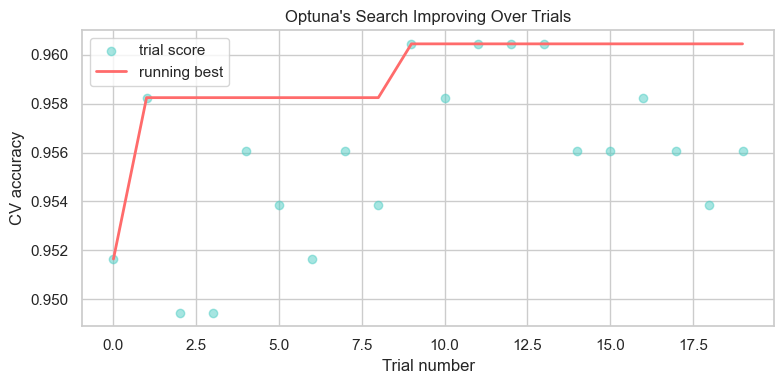

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(range(len(trial_scores)), trial_scores, alpha=0.5, color="#4ecdc4", label="trial score")
ax.plot(range(len(running_best)), running_best, color="#ff6b6b", linewidth=2, label="running best")
ax.set_xlabel("Trial number"); ax.set_ylabel("CV accuracy")
ax.set_title("Optuna's Search Improving Over Trials")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Comparing All Three Search Strategies — Same Budget

Grid (coarse, ~24 combos), Random (20 samples), and Optuna (20 trials) — all roughly the same evaluation budget, compared directly on final held-out test accuracy, not just CV score.


In [19]:
best_grid_model = RandomForestClassifier(**grid_budget.best_params_, random_state=42).fit(X_train, y_train)
best_random_model = RandomForestClassifier(**random_budget.best_params_, random_state=42).fit(X_train, y_train)
best_optuna_model = RandomForestClassifier(**study.best_params, random_state=42).fit(X_train, y_train)

comparison = pd.DataFrame({
    "Method": ["Grid Search", "Random Search", "Optuna (Bayesian)"],
    "Budget": [n_combos, budget, 20],
    "Best CV Score": [grid_budget.best_score_, random_budget.best_score_, study.best_value],
    "Test Accuracy": [
        accuracy_score(y_test, best_grid_model.predict(X_test)),
        accuracy_score(y_test, best_random_model.predict(X_test)),
        accuracy_score(y_test, best_optuna_model.predict(X_test)),
    ],
})
comparison


,Method,Budget,Best CV Score,Test Accuracy
0,Grid Search,24,0.960440,0.95614
1,Random Search,20,0.958242,0.95614
2,Optuna (Bayesian),20,0.960440,0.95614


## 12. Successive Halving — Efficient Resource Allocation

`HalvingGridSearchCV` starts by evaluating *every* candidate on a small amount of data/resources, then only advances the best-performing fraction to the next round with more resources — eliminating clearly-bad candidates early instead of spending full evaluation budget on all of them.


In [20]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

halving_search = HalvingGridSearchCV(
    RandomForestClassifier(random_state=42), coarse_grid,
    cv=5, factor=2, random_state=42
)
halving_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (string) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [50, 150, ...]}"
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for subsampling the datasetwhen `resources != 'n_samples'`. Ignored otherwise.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'n_samples'
,"max_resources max_resources: int, default='auto'The maximum amount of resource that any candidate is allowed to usefor a given iteration. By default, this is set to ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",'auto'
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='exhaust'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",'exhaust'
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for

In [21]:
print(f"Best parameters: {halving_search.best_params_}")
print(f"Best CV score:    {halving_search.best_score_:.4f}")
print(f"Number of candidates evaluated in the final round: {halving_search.n_candidates_[-1]}")
print(f"Number of candidates evaluated in the first round:  {halving_search.n_candidates_[0]}")
print("\n-> Successive halving spent most of its budget narrowing down from many weak candidates")
print("   to few strong ones, rather than fully evaluating every candidate at full cost.")


Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 250}
Best CV score:    0.9551
Number of candidates evaluated in the final round: 2
Number of candidates evaluated in the first round:  24

-> Successive halving spent most of its budget narrowing down from many weak candidates
   to few strong ones, rather than fully evaluating every candidate at full cost.


## 13. Tuning a Different Algorithm — SVM

The same search mechanics apply to any estimator; tuning SVM's `C` and `gamma` (Classification topic 06) demonstrates this isn't Random-Forest-specific machinery.


In [22]:
svm_param_dist = {
    "C": uniform(0.1, 100),
    "gamma": uniform(0.001, 1),
}
svm_random_search = RandomizedSearchCV(
    SVC(kernel="rbf"), svm_param_dist, n_iter=15,
    cv=5, random_state=42
)
svm_random_search.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....0021D1D13A7B0>, 'gamma': <scipy.stats....0021D1E5DF250>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and 

In [23]:
print(f"Best SVM parameters: {svm_random_search.best_params_}")
print(f"Best CV score:        {svm_random_search.best_score_:.4f}")
print(f"Test accuracy:        {accuracy_score(y_test, svm_random_search.predict(X_test)):.4f}")


Best SVM parameters: {'C': np.float64(37.55401188473625), 'gamma': np.float64(0.9517143064099162)}
Best CV score:        0.6264
Test accuracy:        0.6316


## 14. Multi-Metric Scoring

Optimizing for accuracy alone can be the wrong choice on imbalanced data — `GridSearchCV`'s `scoring` parameter accepts multiple metrics at once via `refit=` pointing to whichever should determine the final chosen model.


In [24]:
multi_metric_search = GridSearchCV(
    RandomForestClassifier(random_state=42), coarse_grid,
    scoring=["accuracy", "f1", "roc_auc"], refit="f1", cv=5
)
multi_metric_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [50, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: in

In [25]:
best_idx = multi_metric_search.best_index_
results = multi_metric_search.cv_results_
print(f"Best (by F1) parameters: {multi_metric_search.best_params_}")
print(f"  Accuracy at this config: {results['mean_test_accuracy'][best_idx]:.4f}")
print(f"  F1 at this config:       {results['mean_test_f1'][best_idx]:.4f}")
print(f"  ROC-AUC at this config:  {results['mean_test_roc_auc'][best_idx]:.4f}")


Best (by F1) parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 150}
  Accuracy at this config: 0.9604
  F1 at this config:       0.9684
  ROC-AUC at this config:  0.9874


## 15. Reporting the Final Score Honestly — Nested CV Recap

Straight from the previous topic: `grid_search.best_score_` is a tuning-time number, not an honest final estimate. The correct way to report tuned-model performance is either a genuinely held-out test set (used throughout this notebook) or full nested cross-validation.


In [26]:
final_tuned_model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
final_tuned_model.fit(X_train, y_train)

print(f"CV score during tuning (optimistic):  {grid_search.best_score_:.4f}")
print(f"Held-out test accuracy (honest):      {accuracy_score(y_test, final_tuned_model.predict(X_test)):.4f}")
print("\n-> These two numbers answer different questions: the first is 'how well did tuning fit the")
print("   training folds,' the second is 'how well does the FINAL chosen model generalize to unseen data.'")


CV score during tuning (optimistic):  0.9626
Held-out test accuracy (honest):      0.9561

-> These two numbers answer different questions: the first is 'how well did tuning fit the
   training folds,' the second is 'how well does the FINAL chosen model generalize to unseen data.'


## 16. Wall-Clock Time Comparison

CV score isn't the only cost that matters in practice — comparing how long each search strategy actually took to run, at their respective budgets from section 11.


In [27]:
timings = {}

start = time.time()
GridSearchCV(RandomForestClassifier(random_state=42), coarse_grid, cv=5).fit(X_train, y_train)
timings["Grid Search"] = time.time() - start

start = time.time()
RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions, n_iter=budget, cv=5, random_state=42).fit(X_train, y_train)
timings["Random Search"] = time.time() - start

start = time.time()
study_timed = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_timed.optimize(optuna_objective, n_trials=20, show_progress_bar=False)
timings["Optuna"] = time.time() - start


In [28]:
for name, t in timings.items():
    print(f"{name:15s}: {t:.2f}s")
print("\n-> Optuna's per-trial overhead (fitting its probability model) is real, but usually small")
print("   relative to the cost of the model fits themselves on non-trivial datasets.")


Grid Search    : 15.07s
Random Search  : 15.58s
Optuna         : 15.17s

-> Optuna's per-trial overhead (fitting its probability model) is real, but usually small
   relative to the cost of the model fits themselves on non-trivial datasets.


## 17. Distribution of Scores Across the Full Grid

Beyond just the single best combination, looking at the full spread of scores across every grid combination shows how much tuning actually mattered here — a narrow spread means most configurations were "good enough," a wide spread means tuning was essential.


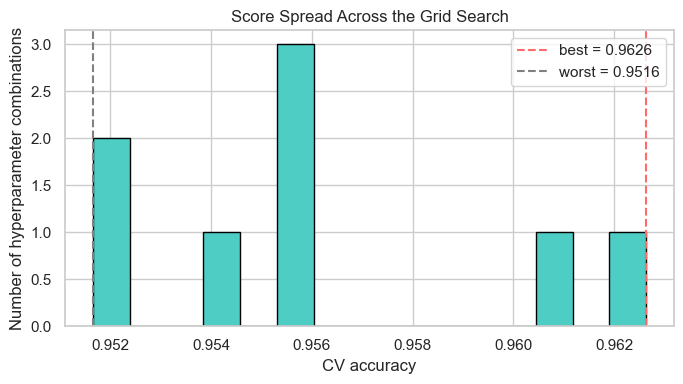

Gap between best and worst combination: 0.0110


In [29]:
all_scores = results_df["mean_test_score"] if "mean_test_score" in results_df.columns else pd.DataFrame(grid_search.cv_results_)["mean_test_score"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(all_scores, bins=15, color="#4ecdc4", edgecolor="black")
ax.axvline(all_scores.max(), color="#ff6b6b", linestyle="--", label=f"best = {all_scores.max():.4f}")
ax.axvline(all_scores.min(), color="gray", linestyle="--", label=f"worst = {all_scores.min():.4f}")
ax.set_xlabel("CV accuracy"); ax.set_ylabel("Number of hyperparameter combinations")
ax.set_title("Score Spread Across the Grid Search")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Gap between best and worst combination: {all_scores.max() - all_scores.min():.4f}")


## 18. Final Chosen Model — Summary


In [30]:
print("=" * 60)
print("FINAL TUNING SUMMARY")
print("=" * 60)
print(f"Best method by test accuracy: {comparison.loc[comparison['Test Accuracy'].idxmax(), 'Method']}")
print(f"Best hyperparameters found (GridSearchCV): {grid_search.best_params_}")
print(f"Final held-out test accuracy: {accuracy_score(y_test, final_tuned_model.predict(X_test)):.4f}")


FINAL TUNING SUMMARY
Best method by test accuracy: Grid Search
Best hyperparameters found (GridSearchCV): {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
Final held-out test accuracy: 0.9561


## ✅ Key Takeaways

- **Grid search** is exhaustive and guaranteed to find the best combination *within the specified grid*, but its cost grows combinatorially with every added hyperparameter.
- **Random search** often matches or beats grid search under an equal budget, especially when only a few hyperparameters actually matter — it explores the important dimensions more densely by chance (section 8).
- **Bayesian optimization (Optuna)** uses previous trials to inform future ones, typically finding strong configurations in fewer evaluations than blind random sampling.
- **Successive halving** eliminates weak candidates early using partial resources, spending full evaluation budget only on the most promising few.
- All of these search strategies use **cross-validation internally** as their scoring engine — this topic is Cross-Validation (previous topic) applied systematically, not a separate mechanism.
- `best_score_` from any search is a **tuning-time** number, not a final honest performance estimate — always validate the chosen configuration on a genuinely held-out split, or use full nested CV.

**Next up:** [03_Evaluation_Metrics](../03_Evaluation_Metrics/) — the full mathematical detail behind every accuracy/precision/recall/F1/ROC-AUC number used casually throughout this series so far.
